In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import sem
from itertools import combinations

In [2]:
# Simulation parameters
N = 100  # total neurons
T = 1000  # time points
dt = 1.0  # ms per time point
ITER = 10  # number of iterations
self_conn = 0.0  # value for self-connections i.e. 0 for no self-connections 

In [3]:
# Neuron type setup (80% RS, 20% FS)
exc_ratio = 0.8
inh_ratio = 0.2
lts_ratio = 0
n_exc = int(N * exc_ratio)
n_lts = int(N * lts_ratio)
n_inh = N - n_exc - n_lts

types = np.array(['RS'] * n_exc + ['FS'] * n_inh + ['LTS'] * n_lts) # options: 'RS', 'FS', 'LTS'

In [4]:
# Izhikevich neuron parameters
def get_izh_params(neuron_type):
    if neuron_type == 'RS':
        return 0.02, 0.2, -65, 8
    elif neuron_type == 'FS':
        return 0.1, 0.2, -65, 2
    elif neuron_type == 'LTS':
        return 0.02, 0.25, -65, 2

In [5]:
# Initialize weights with biological plausibility
def init_weights(method='random', desired_density=0.8, types=None, norm_type='l2',dist='normal'):
    if types is None:
        raise ValueError("types array must be provided")
    assert len(types) == N
    W = np.zeros((N, N))
    if method == 'random':
        W = np.random.rand(N, N) * 0.5
        np.fill_diagonal(W, 0.0)
    elif method == 'random_sparse':
        for i in range(N):
            for j in range(N):
                if i != j and np.random.rand() < desired_density:
                    if dist == 'uniform':
                        W[i, j] = np.random.uniform(0.0, 1.0)
                    elif dist == 'normal':
                        W[i, j] = np.abs(np.random.normal(loc=0.5, scale=0.2))
                    elif dist == 'lognormal':
                        W[i, j] = np.random.lognormal(mean=0.0, sigma=1.0)
        np.fill_diagonal(W, 0.0)
    elif method == 'random_dense':
        for i in range(N):
            for j in range(N):
                if i != j:
                    W[i, j] = np.random.rand() * 0.5
        np.fill_diagonal(W, 0.0)
    elif method == 'lattice':
        radius = 2  # how many neighbors on each side
        for i in range(N):
            for j in range(1, radius + 1):
                right = (i + j) % N
                left = (i - j) % N
                W[i, right] = np.random.rand() * 0.5
                W[i, left] = np.random.rand() * 0.5
        np.fill_diagonal(W, 0.0)
    elif method == 'small_world':
        #A small-world network (like the Watts–Strogatz model) starts from a lattice and rewires a few edges randomly to reduce path length while maintaining high clustering.
        G = nx.watts_strogatz_graph(N, k=4, p=0.1)  # k: neighbors; p: rewiring prob
        W = nx.to_numpy_array(G) * np.random.rand(N, N) * 0.5
        np.fill_diagonal(W, 0.0)
    elif method == 'random_structure_sf_weights':
        N_local = len(types)
        
        k_sf=int(np.ceil(desired_density*N_local))# number of edges each new nodes connects to
        k_sf = max(1, min(k_sf, N_local - 1))# it must be greater than 1
        
        # Generate a scale-free graph (Barabási-Albert model)
        G_sf = nx.barabasi_albert_graph(N_local, k_sf)  
        sf_weights = np.random.rand(G_sf.number_of_edges()) * 0.5 

        # Create a completely random connection mask
        conn_mask = (np.random.rand(N_local, N_local) < desired_density) 
        np.fill_diagonal(conn_mask, 0)

        conn_indices = np.transpose(np.nonzero(conn_mask))

        # Shuffle the scale-free weights and the connection indices
        num_weights = min(len(sf_weights), len(conn_indices))
        np.random.shuffle(sf_weights)
        np.random.shuffle(conn_indices)

        W = np.zeros((N_local, N_local))
        rows, cols = conn_indices[:num_weights].T
        W[rows, cols] = sf_weights[:num_weights]
        
        # Dale's law for FS and LTS: inhibitory neurons only have negative outgoing weights
        for i in range(N_local):
            if types[i] in ['FS', 'LTS']:
                W[i, :] *= -1
            else:
                W[i, :] = np.clip(W[i, :], 0, None)

        np.fill_diagonal(W, 0.0)
        return W

    else:
        raise ValueError("Unknown weight initialization method")
        
    # Dale's law for other methods
    for i in range(N):
        if types[i] in ['FS', 'LTS']:
            W[i, :] *= -1  
        else:
            W[i, :] = np.clip(W[i, :], 0, None)
    np.fill_diagonal(W, 0.0)
    return W

In [6]:
def hebbian_update(W, spikes, lr=0.01):
    for t in range(1, T):
        pre = spikes[:, t-1]
        post = spikes[:, t]
        delta_w = lr * np.outer(post, pre)
        W += delta_w
        # Re-apply Dale's law
        for i in range(N):
            if types[i] in ['FS', 'LTS']:
                W[i, :] = np.clip(W[i, :], None, 0)
            else:
                W[i, :] = np.clip(W[i, :], 0, None)
    np.fill_diagonal(W, 0.0)
    return W

In [7]:
# Simulate one iteration of activity
def simulate(W, plasticity=True, noise_std=1.0):
    spikes = np.zeros((N, T))
    v = np.full(N, -65.0)
    u = np.zeros(N)
    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)
    d = np.zeros(N)

    # Set neuron parameters
    for i in range(N):
        a[i], b[i], c[i], d[i] = get_izh_params(types[i])
        u[i] = b[i] * v[i]

    for t in range(1, T):
        I = np.dot(W, spikes[:, t-1]) + np.random.normal(10, noise_std, N)  # input current
        fired = v >= 30
        spikes[fired, t] = 1
        v[fired] = c[fired]
        u[fired] += d[fired]

        v += dt * (0.04 * v**2 + 5 * v + 140 - u + I)
        u += dt * a * (b * v - u)

    if plasticity:
        W = hebbian_update(W, spikes)

    return spikes, W

In [8]:
def analyze(spikes, W):
    firing_rates = spikes.mean(axis=1) / (dt * 1e-3)
    avg_rate = np.mean(firing_rates)
    cv = np.std(firing_rates) / np.mean(firing_rates)
    
    G = nx.from_numpy_array(np.abs(W), create_using=nx.DiGraph)
    avg_degree = np.mean([deg for _, deg in G.degree(weight='weight')])
    clustering = nx.average_clustering(G.to_undirected(), weight='weight')
    node_strength = np.sum(np.abs(W), axis=1)

    return {
        'avg_rate': avg_rate, #Mean firing rate (Hz)
        'cv': cv, #Variability of firing across neurons
        'avg_degree': avg_degree, #Average weighted degree (connectivity)
        'clustering': clustering, # Average clustering coefficient
        'strength_mean': np.mean(node_strength), #Mean outgoing connection strength
        'strength_sem': sem(node_strength), # Standard error of that mean
    }

In [9]:
import numpy as np
import networkx as nx
from scipy.stats import sem

def analyze_by_type(spikes, W, types, dt):
    assert len(types) == N

    dt_sec = dt * 1e-3
    firing_rates = spikes.mean(axis=1) / dt_sec
    node_strength = np.sum(np.abs(W), axis=1)
    
    G = nx.from_numpy_array(np.abs(W), create_using=nx.DiGraph)
    avg_degree = np.mean([deg for _, deg in G.degree(weight='weight')])
    clustering = nx.average_clustering(G.to_undirected(), weight='weight')

    results = {
        'overall': {
            'avg_rate': np.mean(firing_rates),
            'cv': np.std(firing_rates) / np.mean(firing_rates),
            'avg_degree': avg_degree,
            'clustering': clustering,
            'strength_mean': np.mean(node_strength),
            'strength_sem': sem(node_strength),
        }
    }

    # Split by neuron type
    unique_types = np.unique(types)
    for t in unique_types:
        idx = np.where(types == t)[0]
        rates_t = firing_rates[idx]
        strength_t = node_strength[idx]
        
        results[str(t)] = {
            'avg_rate': np.mean(rates_t),
            'cv': np.std(rates_t) / np.mean(rates_t) if np.mean(rates_t) > 0 else np.nan,
            'strength_mean': np.mean(strength_t),
            'strength_sem': sem(strength_t),
        }

    return results


In [10]:
# Run ITER simulations
import pandas as pd
all_metrics = []
all_spike_matrices = []
all_weight_matrices = []

for it in range(ITER):
    N = len(types)
    W0 = init_weights(method='random_sparse', types=types)  # or 'random', 'lattice', 'small_world', 'scale_free', 'random_sparse', 'random_dense'
    spikes, W_final = simulate(W0)
   # metrics = analyze(spikes, W_final)
    metrics = analyze_by_type(spikes, W_final, types, dt)
    flat_metrics = {}
    for group, values in metrics.items():
        for k, v in values.items():
            flat_metrics[f'{group}_{k}'] = v
    all_metrics.append(flat_metrics)
    all_spike_matrices.append(spikes)
    all_weight_matrices.append(W_final)


metrics_df = pd.DataFrame(all_metrics)

/Users/luxueqi/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/luxueqi/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [11]:
print(metrics_df.mean(numeric_only=True))

overall_avg_rate         31.396000
overall_cv                0.538782
overall_avg_degree       82.087236
overall_clustering        0.308221
overall_strength_mean    41.043618
overall_strength_sem      0.317033
FS_avg_rate              65.190000
FS_cv                     0.017337
FS_strength_mean         37.594710
FS_strength_sem           0.558707
RS_avg_rate              22.947500
RS_cv                     0.028124
RS_strength_mean         41.905845
RS_strength_sem           0.299282
dtype: float64


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def plot_population_fourier(all_spike_matrices, neuron_type, types, dt=1.0):
    assert len(types) == N

    # Find indices of the selected neuron type 
    neuron_indices = [i for i, t in enumerate(types) if t == neuron_type]
    
    if not neuron_indices:
        print(f"No neurons of type {neuron_type} found.")
        return

    # Accumulate total population activity over all simulations
    summed_signal = None
    for spikes in all_spike_matrices:
        activity = spikes[neuron_indices].sum(axis=0)
        if summed_signal is None:
            summed_signal = activity
        else:
            summed_signal += activity
    
    # Normalize by number of simulations
    summed_signal = summed_signal / len(all_spike_matrices)
    
    # Time and frequency vectors
    T = summed_signal.shape[0]
    time = np.arange(T) * dt / 1000  # seconds
    freqs = fftfreq(T, dt / 1000)    # Hz

    # Perform FFT
    signal_fft = fft(summed_signal)
    power = np.abs(signal_fft)**2
    freqs_pos = freqs[:T // 2]
    power_pos = power[:T // 2]
    power_pos[0] = 0

    plt.figure(figsize=(8, 4))
    plt.plot(freqs_pos, power_pos)
    plt.title(f'Population Power Spectrum ({neuron_type})')
    if neuron_type == 'RS':
        plt.xlim(0, 100)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return power_pos

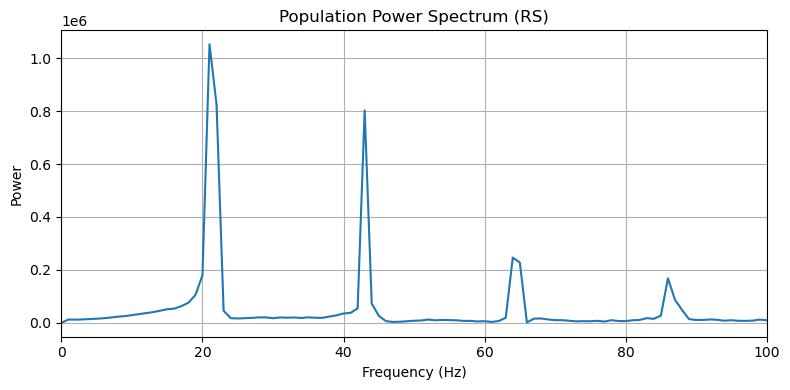

array([0.00000000e+00, 1.22662307e+04, 1.19442233e+04, 1.27144070e+04,
       1.39406053e+04, 1.54205284e+04, 1.72383868e+04, 1.99159273e+04,
       2.31560628e+04, 2.51903420e+04, 2.90316551e+04, 3.27517368e+04,
       3.69243958e+04, 4.03231666e+04, 4.59529630e+04, 5.11565745e+04,
       5.35313786e+04, 6.27097328e+04, 7.57306628e+04, 1.04784377e+05,
       1.79529531e+05, 1.05271238e+06, 8.24037114e+05, 4.54813520e+04,
       1.74113132e+04, 1.65127083e+04, 1.73220878e+04, 1.86189771e+04,
       2.03757289e+04, 2.04139743e+04, 1.72518952e+04, 2.02560530e+04,
       1.91945599e+04, 2.01145255e+04, 1.82819753e+04, 2.06034561e+04,
       1.90040323e+04, 1.87923054e+04, 2.34574233e+04, 2.81588257e+04,
       3.52869126e+04, 3.74462368e+04, 5.47189120e+04, 8.02933453e+05,
       7.27427391e+04, 2.65326848e+04, 6.42701884e+03, 3.21601362e+03,
       4.03438850e+03, 5.82513958e+03, 7.74058917e+03, 8.65714159e+03,
       1.22096527e+04, 9.47847151e+03, 1.07520662e+04, 1.01748074e+04,
      

In [13]:
plot_population_fourier(all_spike_matrices, 'RS', dt=1.0, types=types)

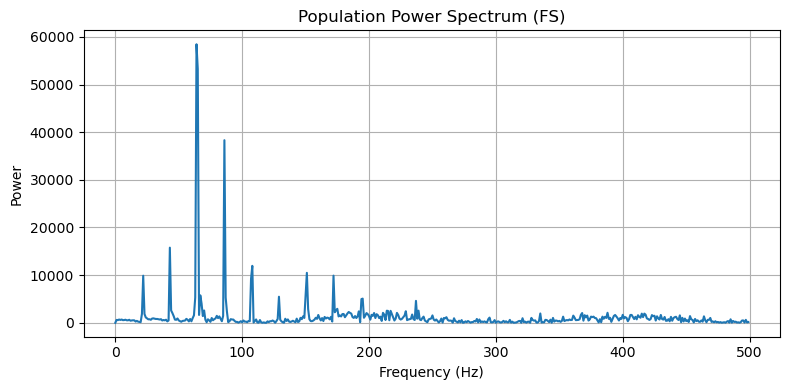

array([0.00000000e+00, 6.06559809e+02, 5.63750047e+02, 6.82888967e+02,
       5.99257648e+02, 6.85402276e+02, 5.54855536e+02, 5.76166699e+02,
       6.43860392e+02, 5.28911686e+02, 5.21291018e+02, 6.28074431e+02,
       4.29948821e+02, 4.97101456e+02, 5.23041409e+02, 5.14830836e+02,
       2.62702087e+02, 3.97243285e+02, 2.43046014e+02, 1.91448556e+02,
       1.38313479e+02, 1.89430280e+03, 9.88149617e+03, 1.85676563e+03,
       1.13437562e+03, 9.26620112e+02, 7.28751474e+02, 7.41880721e+02,
       6.33411803e+02, 8.87652111e+02, 9.28523168e+02, 8.56394340e+02,
       7.97340110e+02, 8.06833224e+02, 7.59253754e+02, 6.88676661e+02,
       7.55169439e+02, 4.87647968e+02, 5.83588448e+02, 5.21785826e+02,
       6.44985614e+02, 2.96044639e+02, 4.87010592e+02, 1.57656046e+04,
       2.58753718e+03, 2.04737521e+03, 1.41573334e+03, 6.72167318e+02,
       6.26169465e+02, 9.11104612e+02, 5.04209364e+02, 3.39641467e+02,
       2.25885116e+02, 3.90711164e+02, 4.36212085e+02, 4.77109652e+02,
      

In [14]:
plot_population_fourier(all_spike_matrices, 'FS', dt=1.0, types=types)

In [15]:
plot_population_fourier(all_spike_matrices, 'LTS', dt=1.0, types=types)

No neurons of type LTS found.


In [16]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

def fourier_analysis(spikes, dt=0.1, neuron_indices=None, plot=False):
    N, T = spikes.shape
    time = np.arange(T) * dt / 1000  # convert ms to seconds
    freqs = fftfreq(T, dt / 1000)   # frequencies in Hz

    if neuron_indices is None:
        neuron_indices = range(N)

    power_spectra = {}
    dominant_frequencies = []
    
    for i in neuron_indices:
        signal = spikes[i]  # binary spike train
        signal_fft = fft(signal)
        power = np.abs(signal_fft)**2
        freqs_pos = freqs[:T // 2]
        power_pos = power[:T // 2]

        dom_freq = freqs_pos[np.argmax(power_pos)]
        dominant_frequencies.append(dom_freq)

        power_spectra[i] = (freqs_pos, power_pos)

        if plot:
            plt.figure()
            plt.plot(freqs[:T // 2], power[:T // 2])
            plt.title(f'Neuron {i} Power Spectrum')
            plt.xlabel('Frequency (Hz)')
            plt.ylabel('Power')
            plt.grid()
            plt.show()

    return power_spectra



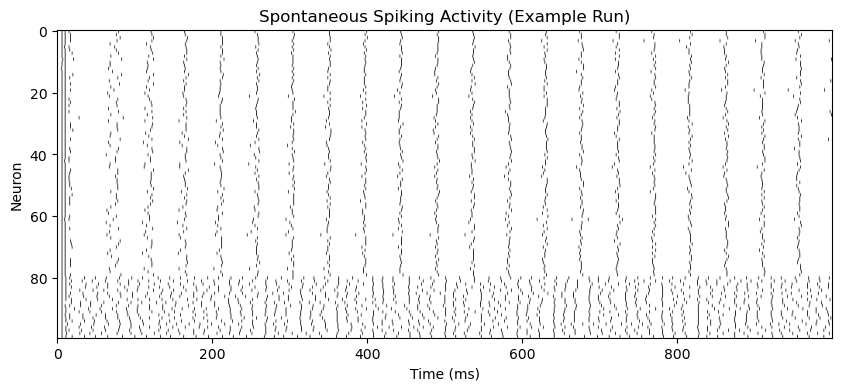

In [17]:
# Plot example activity
plt.figure(figsize=(10, 4))
plt.imshow(all_spike_matrices[9], aspect='auto', cmap='gray_r')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.title('Spontaneous Spiking Activity (Example Run)')
plt.show()

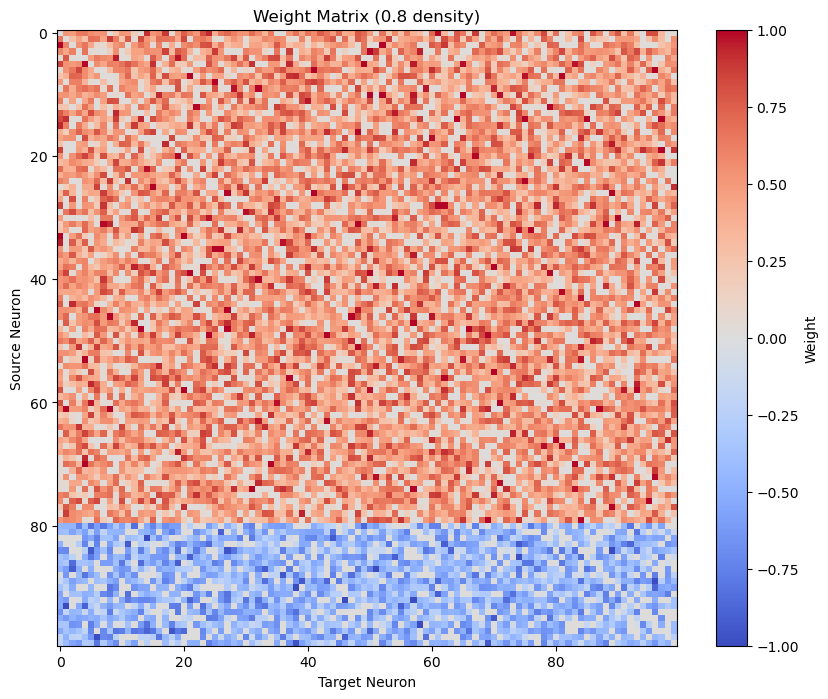

In [18]:
# plot weight matrix
plt.figure(figsize=(10, 8))
# set colormap to red white blue centred on 0
plt.imshow(all_weight_matrices[9], cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Weight')
plt.title('Weight Matrix (0.8 density)')
plt.xlabel('Target Neuron')
plt.ylabel('Source Neuron')
plt.show()

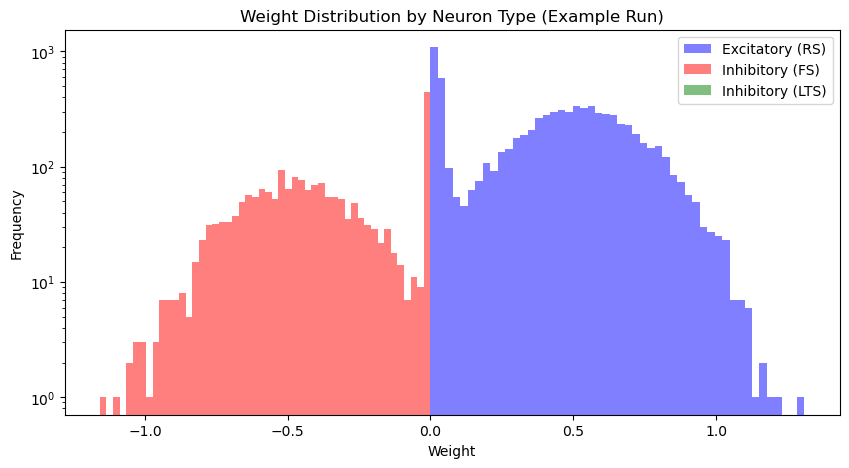

In [19]:
# plot weight distribution for excitatory and inhibitory neurons for the first iteration
plt.figure(figsize=(10, 5))
exc_weights = all_weight_matrices[9][types == 'RS']
inh_weights = all_weight_matrices[9][types == 'FS']
lts_weights = all_weight_matrices[9][types == 'LTS']
plt.hist(exc_weights.flatten(), bins=50, alpha=0.5, label='Excitatory (RS)', color='blue')
plt.hist(inh_weights.flatten(), bins=50, alpha=0.5, label='Inhibitory (FS)', color='red')
plt.hist(lts_weights.flatten(), bins=50, alpha=0.5, label='Inhibitory (LTS)', color='green')
plt.title('Weight Distribution by Neuron Type (Example Run)')
# plt.xscale('log')
plt.yscale('log')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.legend()
plt.show()

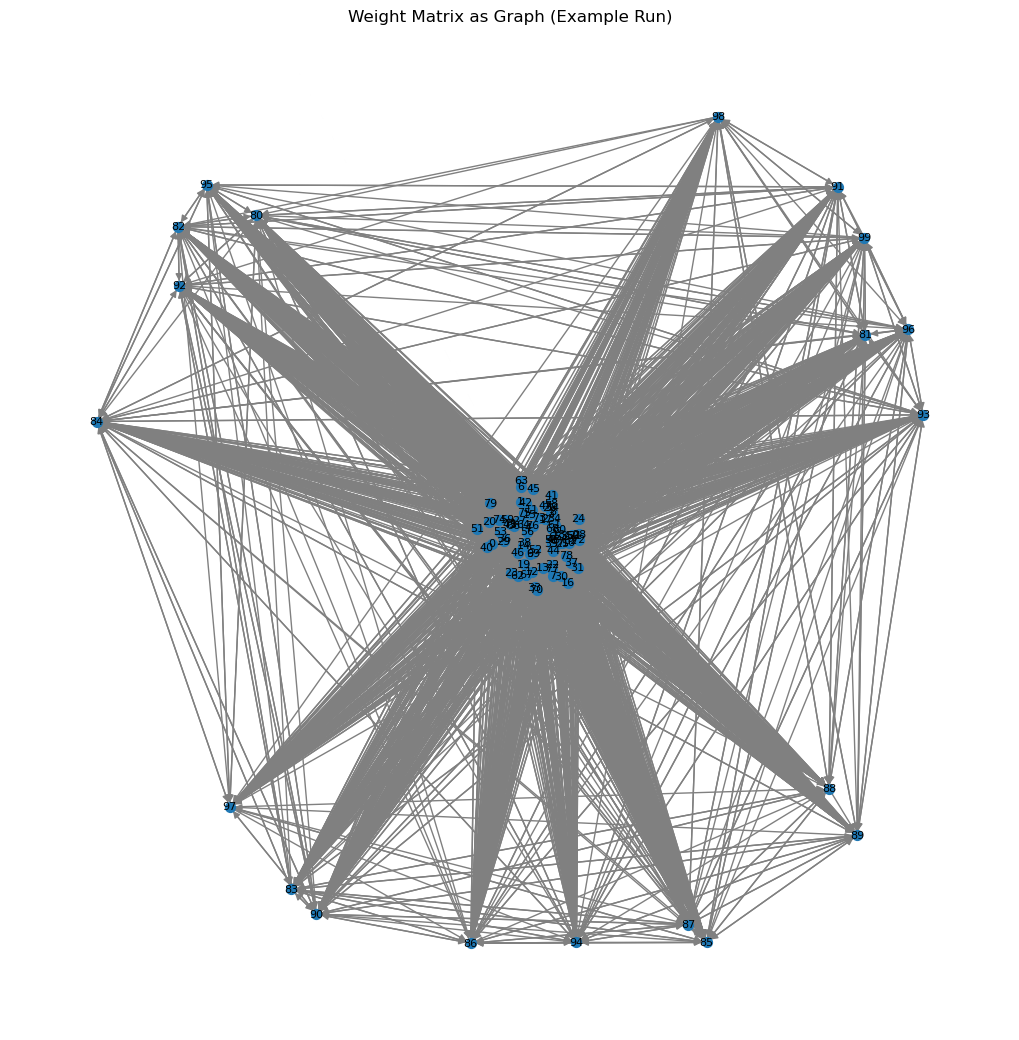

In [20]:
# plot graph of the weight matrix for the first iteration
plt.figure(figsize=(10, 10))
G = nx.from_numpy_array(all_weight_matrices[9], create_using=nx.DiGraph)
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
nx.draw(G, pos, with_labels=True, node_size=50, font_size=8, edge_color='gray', arrows=True)
plt.title('Weight Matrix as Graph (Example Run)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

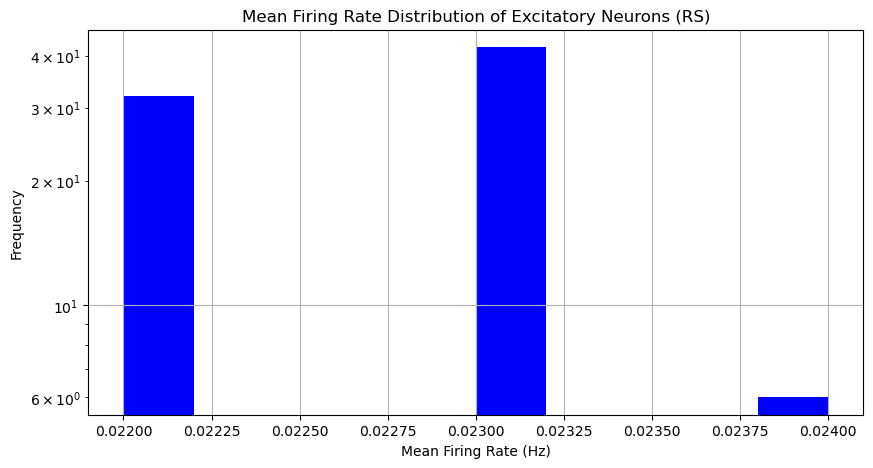

In [21]:
# get mean firing rate of each excitatory neuron for final iteration
mean_firing_rates = np.mean(all_spike_matrices[-1][types == 'RS'], axis=1) / (T * dt * 1e-3)
# plot mean distribution of firing rates of excitatory neurons
plt.figure(figsize=(10, 5))
plt.hist(mean_firing_rates, color='blue')
plt.title('Mean Firing Rate Distribution of Excitatory Neurons (RS)')
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('Frequency')
# plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

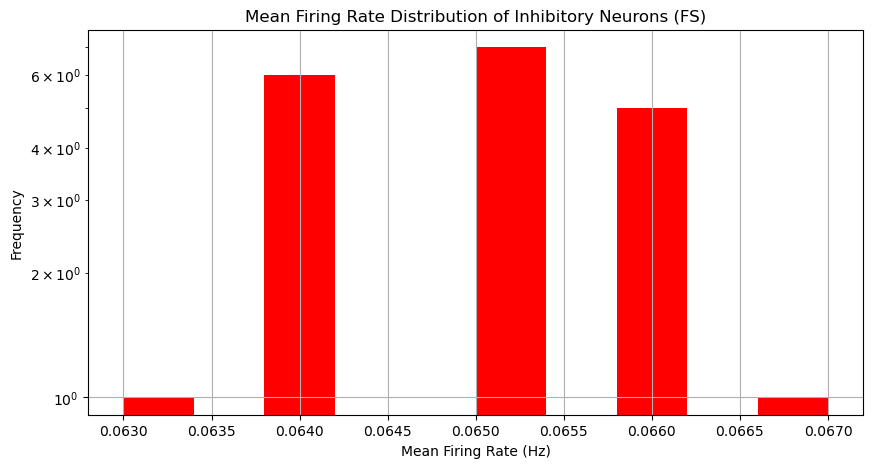

In [22]:
# repeat for inhibitory neurons
mean_firing_rates_inh = np.mean(all_spike_matrices[-1][types == 'FS'], axis=1) / (T * dt * 1e-3)
plt.figure(figsize=(10, 5))
plt.hist(mean_firing_rates_inh, color='red')
plt.title('Mean Firing Rate Distribution of Inhibitory Neurons (FS)')
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('Frequency')
# plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

/var/folders/q_/v6073c7179x4wk0ftwdqqk6c0000gn/T/ipykernel_14988/2537206034.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


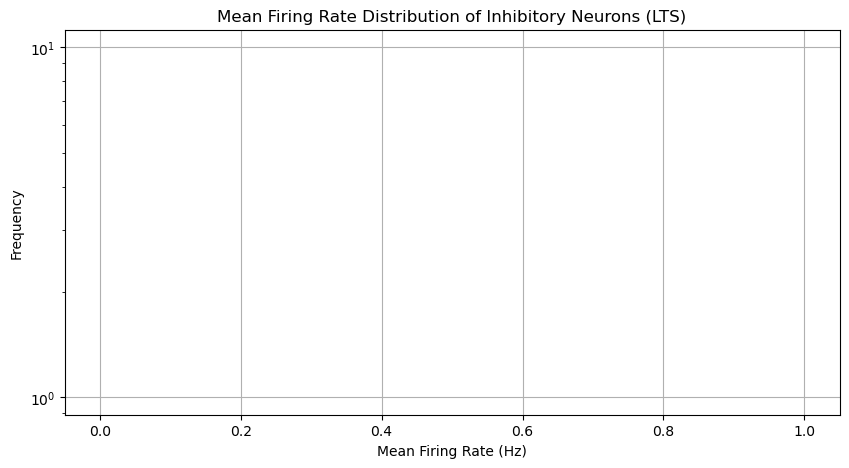

In [23]:
# repeat for lts
mean_firing_rates_inh = np.mean(all_spike_matrices[-1][types == 'LTS'], axis=1) / (T * dt * 1e-3)
plt.figure(figsize=(10, 5))
plt.hist(mean_firing_rates_inh, color='green')
plt.title('Mean Firing Rate Distribution of Inhibitory Neurons (LTS)')
plt.xlabel('Mean Firing Rate (Hz)')
plt.ylabel('Frequency')
# plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

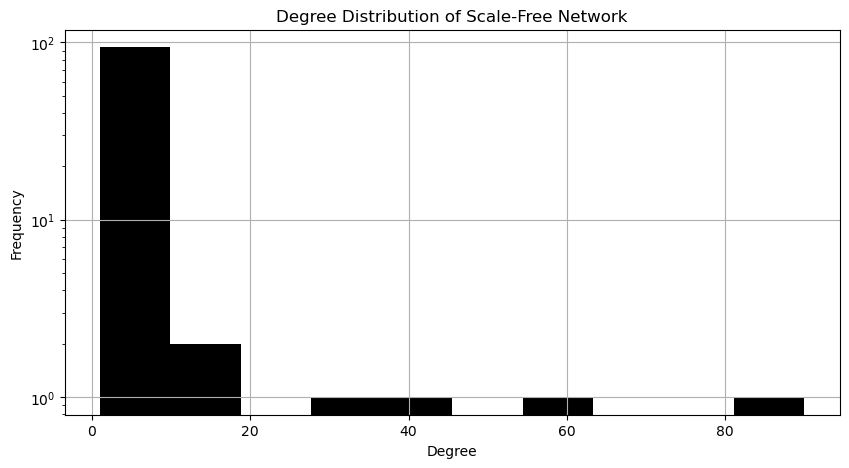

In [24]:
# generate scale-free network and plot its degree distribution
G = nx.scale_free_graph(N)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)  # degree sequence
plt.figure(figsize=(10, 5))
plt.hist(degree_sequence, color='black')
plt.title('Degree Distribution of Scale-Free Network')
# plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

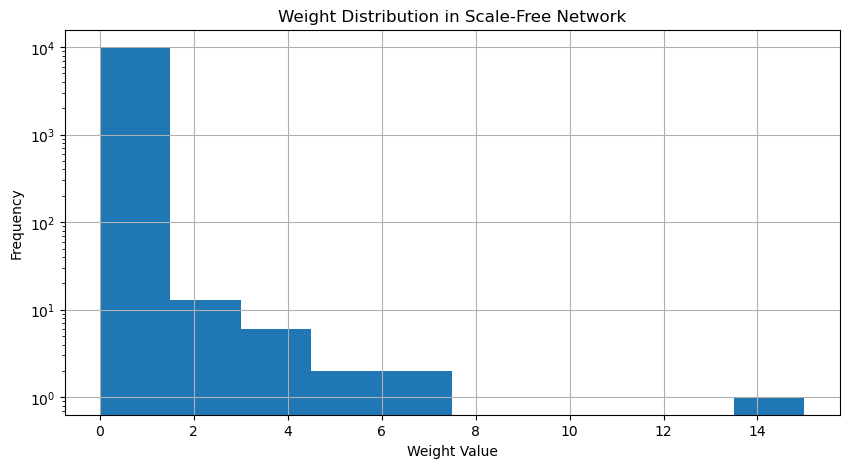

In [25]:
# # plot distribution of values in nx.to_numpy_array(G)
plt.figure(figsize=(10, 5))
plt.hist(nx.to_numpy_array(G).flatten())
plt.title('Weight Distribution in Scale-Free Network')
# plt.xscale('log')
plt.yscale('log')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

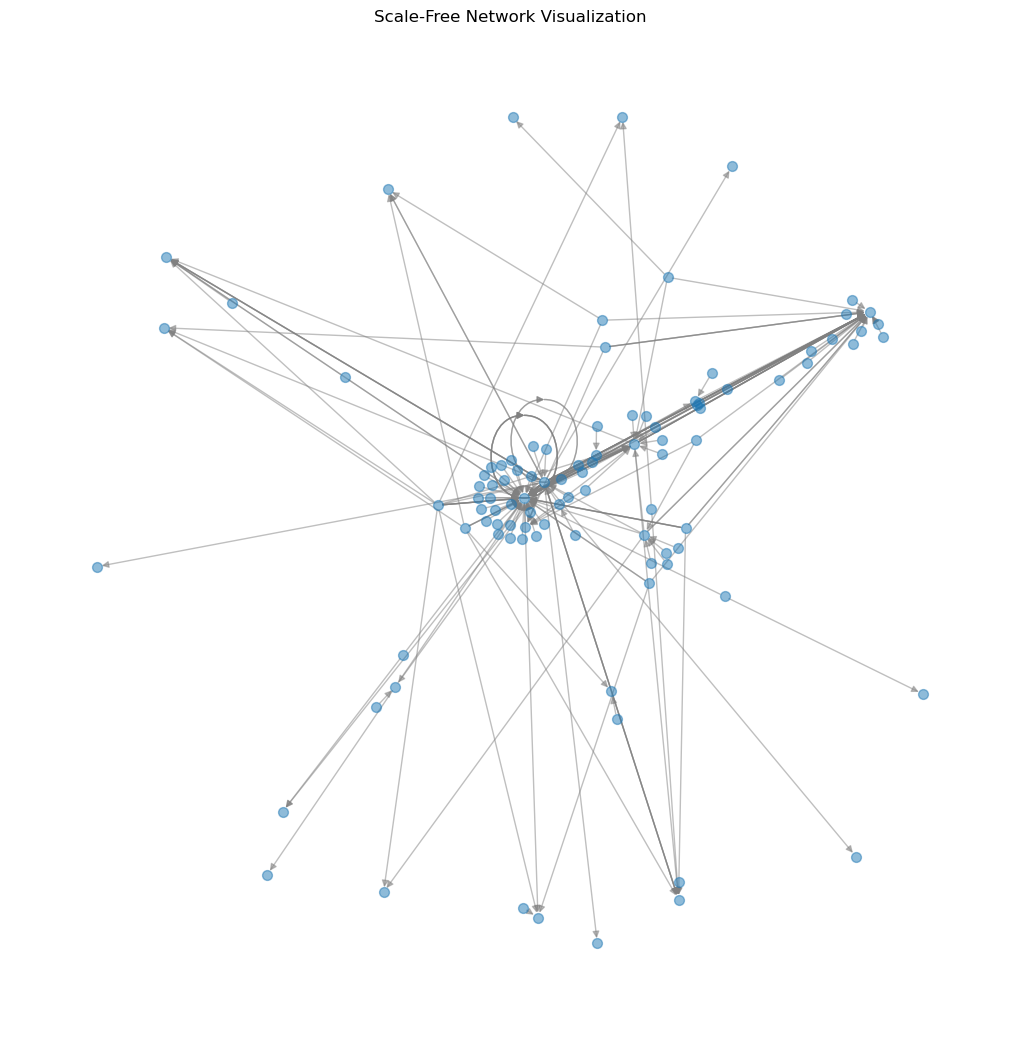

In [26]:
# plot network G in 2D
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)  # positions for all nodes
nx.draw(G, pos, node_size=50, with_labels=False, edge_color='gray', alpha=0.5)
plt.title('Scale-Free Network Visualization')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

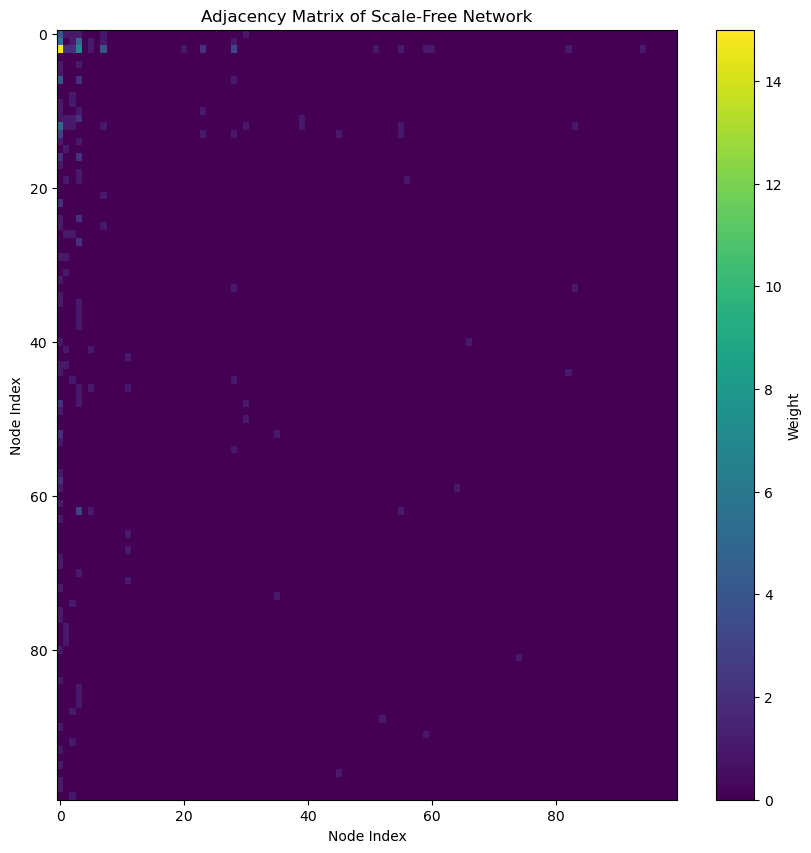

In [27]:
# plot G as an adjacency matrix
plt.figure(figsize=(10, 10))
plt.imshow(nx.to_numpy_array(G), cmap='viridis', aspect='auto')
plt.colorbar(label='Weight')
plt.title('Adjacency Matrix of Scale-Free Network')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.show()